<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
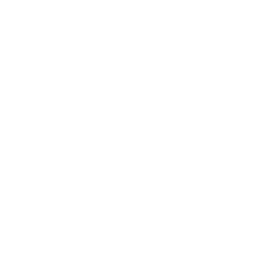
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Chemical Reactor Upset Diagnosis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identify variables driving reactor T2 exceedance during upset event &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Samenvatting

Een continu geroerde tankreactor (CSTR) raakte in een thermische storing
toen de koelmiddeltoevoer terugliep. Onder normale bedrijfsomstandigheden
bewegen het koelmiddeldebiet, de reactortemperatuur en de manteltemperatuur
gezamenlijk langs één procesbelastingsas. We bouwen een MVP-model met drie
componenten op basis van 100 waarnemingen tijdens normaal bedrijf, en
scoren vervolgens 100 storingswaarnemingen ertegen met `PROC MVPDIAGNOSE`.
Door Hotelling's *T*-kwadraatstatistiek te ontleden in bijdragen per
variabele wordt het thermisch gekoppelde trio — `jacket_temp`,
`coolant_flow` en `reactor_temp` — geïsoleerd als de variabelen die de
overschrijding veroorzaken, wat de operatie rechtstreeks naar het
koelsysteem wijst.


## Gegevensbronnen

| Dataset | Rol | Waarnemingen |
|---|---|---|
| `reactor_normal` | Trainingsgegevens tijdens normaal bedrijf voor het MVP-model | 100 |
| `reactor_upset` | Storingswaarnemingen gescoord tegen het model | 100 |

De zes gemeten variabelen zijn `reactor_temp` (C), `coolant_flow`
(L/min), `jacket_temp` (C), `feed_conc` (g/L) en `pressure` (bar).
Beide datasets zijn gesimuleerd vanuit een gedeelde latente
*procesbelasting*, zodat de normale gegevens dezelfde correlatiestructuur
vertonen als een echte CSTR; de storing introduceert een verlies van
koelmiddeltoevoer dat die structuur doorbreekt.


## Stap 1 — Train het MVP-model voor normaal bedrijf

Normaal bedrijf wordt bepaald door een latente procesbelasting: een hogere
belasting trekt het koelmiddeldebiet omlaag terwijl de reactor- en
manteltemperatuur omhoog gaan. `PROC MVPMODEL` extraheert drie
hoofdcomponenten uit de 100 normale waarnemingen en bewaart ze met
`OUTMODEL=` zodat de diagnosestap nieuwe gegevens tegen dezelfde
referentie kan scoren.


In [1]:
GEGEVENS reactor_normal;
  CALL streaminit(7);
  DOE t = 1 TOT 100;
    load = rand('normal', 0, 1);                 /* latente procesbelasting */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    UITVOER;
  EINDE;
UITVOEREN;

PROC mvpmodel GEGEVENS=reactor_normal outmodel=reactor_model;
  VARIABELE reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
UITVOEREN;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         reactor_tempcoolant_flowjacket_temp feed_conc  pressure
  reactor_temp    1.0000   -0.9611    0.9530   -0.0726    0.9662
  coolant_flow   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  jacket_temp    0.9530   -0.9636    1.0000    0.0008    0.9720
  feed_conc   -0.0726    0.0281    0.0008    1.0000   -0.0326
  pressure    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Stap 2 — Score de storing en ontleed *T*-kwadraat

De storing verlaagt het koelmiddeldebiet met ongeveer 12 L/min terwijl de
reactor- en manteltemperatuur oplopen — de normale koppeling tussen
koelmiddel en temperatuur is doorbroken. `PROC MVPDIAGNOSE` scoort elke
storingswaarneming tegen het referentiemodel en schrijft de
gestandaardiseerde scores en residuen naar `OUT=` en de bijdragen per
variabele aan *T*-kwadraat naar `OUTCONTRIB=`. Elke waarneming komt ver
buiten de regelgrens terecht, wat een aanhoudende multivariate afwijking
bevestigt in plaats van geïsoleerde ruis.


In [2]:
GEGEVENS reactor_upset;
  CALL streaminit(101);
  DOE t = 1 TOT 100;
    load = rand('normal', 0, 1);
    /* Koelmiddelpomp degradeert: debiet daalt, temperaturen lopen op */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    UITVOER;
  EINDE;
UITVOEREN;

PROC mvpdiagnose GEGEVENS=reactor_upset MODEL=reactor_model
                 out=reactor_scores;
  VARIABELE reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
UITVOEREN;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Stap 3 — Rangschik de gemiddelde bijdragen

`OUTCONTRIB=` schrijft één rij per gescoorde waarneming met een
`<variabele>_CONTRIB`-kolom voor elke procesvariabele. Door die kolommen
te middelen krijgen we de gemiddelde bijdrage van elke variabele aan de
storing; een transpositie herschikt de samenvatting van één rij tot een
overzichtelijke variabele/waarde-tabel die de storingsfactoren
rangschikt.


In [3]:
PROC MEANS GEGEVENS=reactor_contrib mean NOPRINT;
  VARIABELE reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  UITVOER out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
UITVOEREN;

PROC TRANSPOSE GEGEVENS=contrib_means out=contrib_long name=metric;
  VARIABELE mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
UITVOEREN;

/* Voeg leesbare variabelenamen en de gemiddelde-bijdragewaarde toe */
GEGEVENS contrib_ranked;
  INSTELLEN contrib_long;
  LENGTE variable $25;
  ALS      metric = 'mc_reactor_temp' DAN variable = 'Reactortemperatuur';
  ANDERS ALS metric = 'mc_coolant_flow' DAN variable = 'Koelmiddeldebiet';
  ANDERS ALS metric = 'mc_jacket_temp'  DAN variable = 'Manteltemperatuur';
  ANDERS ALS metric = 'mc_feed_conc'    DAN variable = 'Voedingsconcentratie';
  ANDERS ALS metric = 'mc_pressure'     DAN variable = 'Druk';
  mean_contrib = col1;
  BEWAREN variable mean_contrib;
UITVOEREN;

PROC SORT GEGEVENS=contrib_ranked;
  VOLGENS AFLOPEND mean_contrib;
UITVOEREN;

PROC PRINT GEGEVENS=contrib_ranked noobs label;
  VARIABELE variable mean_contrib;
  label variable='Procesvariabele' mean_contrib='Gemiddelde T-kwadraatbijdrage';
UITVOEREN;



     Procesvariabele  Gemiddelde T-kwadraatbijdrage
--------------------  -----------------------------
Manteltemperatuur                     4177.66720283
Koelmiddeldebiet                      2882.19501987
Reactortemperatuur                    1602.04200377
Druk                                   280.73140863
Voedingsconcentratie                    61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/04f1a8e4-2497-41be-80af-de6767b6eccf/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Stap 4 — Bijdrageplot

De bijdrageplot maakt de diagnose direct duidelijk: het thermisch
gekoppelde trio — `jacket_temp`, `coolant_flow` en `reactor_temp` —
overschaduwt `feed_conc` en `pressure`, die nauwelijks meetbaar zijn. De
drie dominante balken zijn precies de variabelen die door de koellus aan
elkaar gekoppeld zijn, dus de storing is ondubbelzinnig thermisch van
aard, en geen voedings- of drukprobleem.



NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


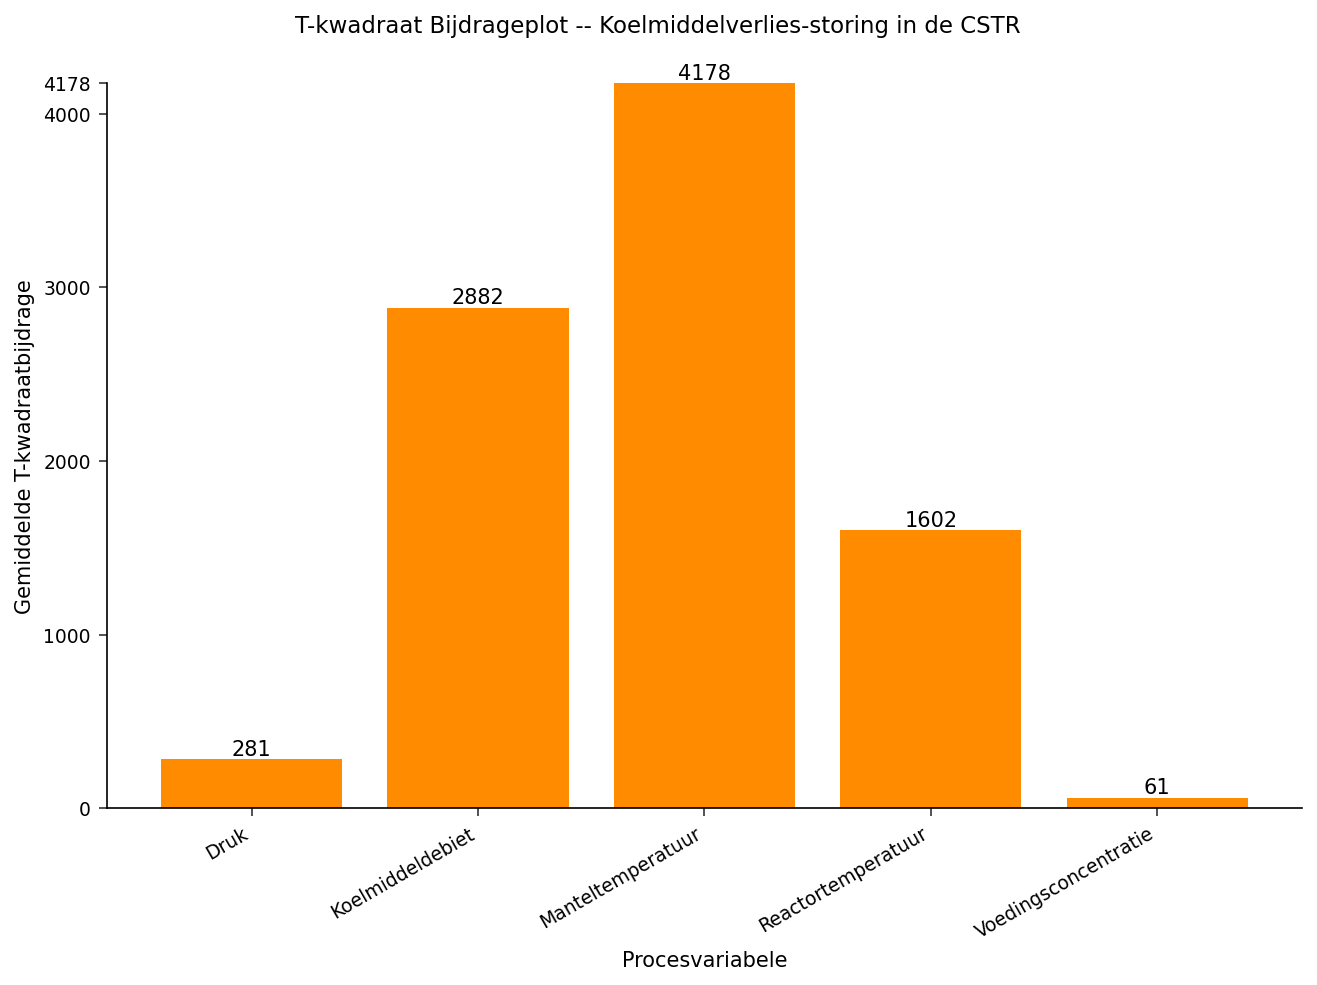

In [4]:
PROC SGPLOT GEGEVENS=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS label='Procesvariabele';
  YAXIS label='Gemiddelde T-kwadraatbijdrage';
  TITEL 'T-kwadraat Bijdrageplot -- Koelmiddelverlies-storing in de CSTR';
UITVOEREN;


## Stap 5 — *T*-kwadraat regeltijdlijn

Door de *T*-kwadraat van elke waarneming tegen de regelgrens van het
model uit te zetten, blijkt de afwijking continu: elke storingswaarneming
ligt orden van grootte boven de referentielijn van de grens. Er is geen
herstel binnen het venster, wat overeenkomt met een hardwarestoring die
aanhoudt totdat het koelsysteem is onderhouden.



NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


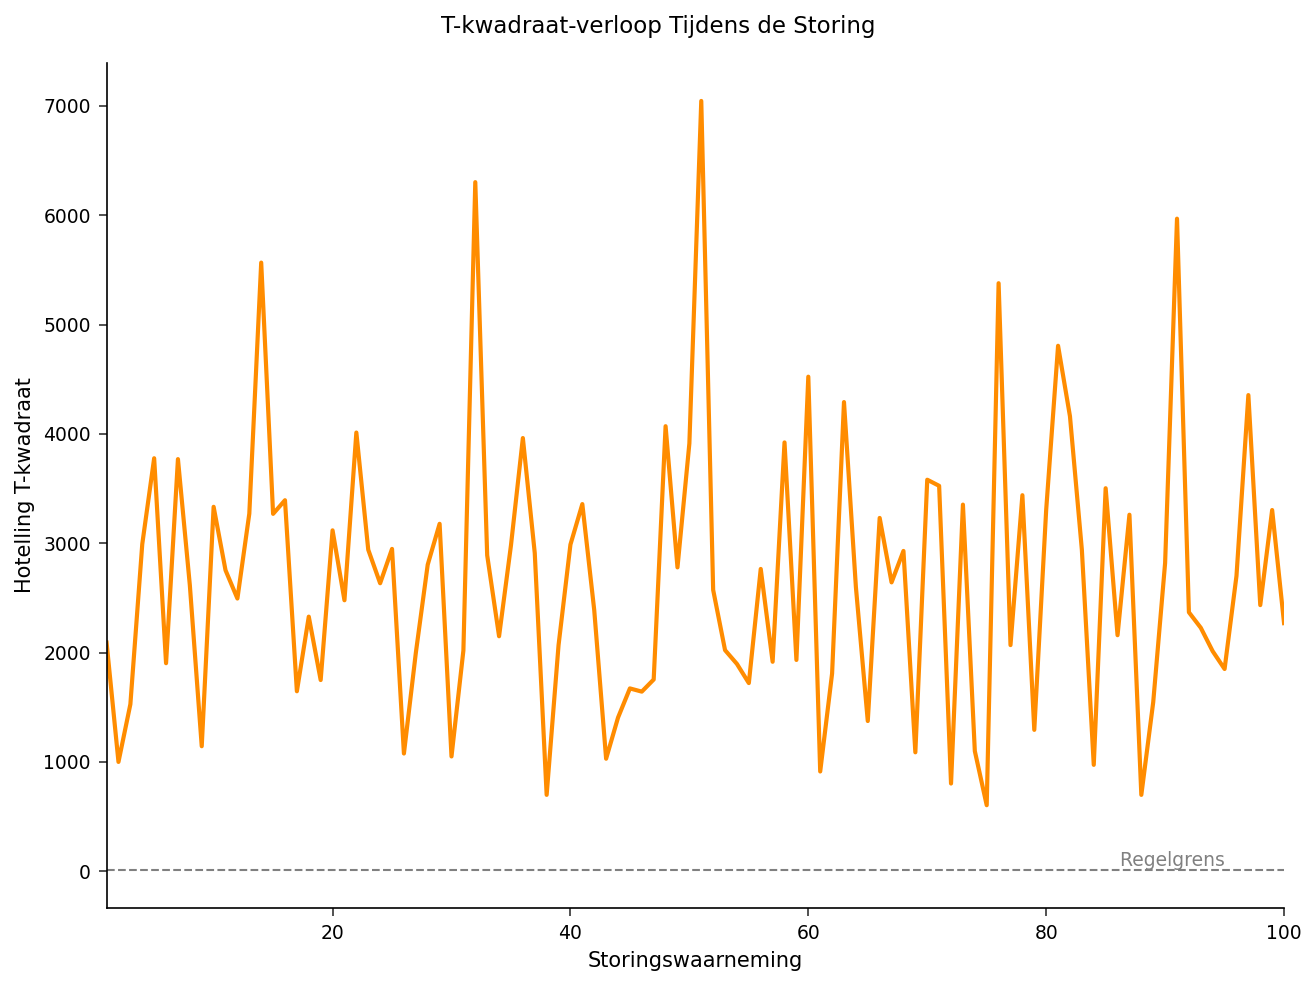

In [5]:
PROC SGPLOT GEGEVENS=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  label='Regelgrens'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS label='Storingswaarneming';
  YAXIS label='Hotelling T-kwadraat';
  TITEL 'T-kwadraat-verloop Tijdens de Storing';
UITVOEREN;


## Bevindingen &amp; Corrigerende Actie

- **Belangrijkste factoren**: `jacket_temp`, `coolant_flow` en
  `reactor_temp` zijn samen verantwoordelijk voor vrijwel het volledige
  *T*-kwadraatsignaal; hun gemiddelde bijdragen liggen twee tot drie
  ordes van grootte boven `feed_conc` en `pressure`.
- **Grondoorzaak**: een verlies van koelmiddeltoevoer. `coolant_flow` is
  de enige *gemanipuleerde* variabele van de drie — de
  temperatuurstijgingen zijn stroomafwaartse gevolgen van het verlies van
  koeling, dus de aanpakbare storing is het koelsysteem.
- **Regelstatus**: alle 100 storingswaarnemingen overschrijden de
  *T*-kwadraatgrens, wat wijst op een aanhoudende afwijking in plaats van
  een tijdelijke uitschieter.
- **Corrigerende actie**: inspecteer en reviseer de koelmiddelpomp; voeg
  een redundante koelmiddeldebiettransmitter toe zodat een toekomstig
  verlies van toevoer wordt opgemerkt door univariate alarmering voordat
  het doorwerkt in de temperatuurlus.


## Exporteer de gerangschikte bijdragen

De gerangschikte bijdragetabel wordt weggeschreven naar CSV voor het
rapport na afloop en downstream-dashboards.


In [6]:
PROC EXPORT GEGEVENS=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
UITVOEREN;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>